# INF2005 steganography: an end-to-end demonstration

This notebook follows one message from a sender to a receiver. The sender writes a
stego carrier and a public-key PEM file; the receiver then uses only those files.
The implementation supports strict RGB PNG and uncompressed PCM WAV carriers.

## Setup

The tracked `samples/Banana.png` file is the PNG cover. Every generated file is
written to a temporary directory and removed at the end.

In [1]:
import sys
import tempfile
import wave
from datetime import datetime, timezone
from pathlib import Path

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "stego" / "__init__.py").exists():
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT))

import numpy as np
from IPython.display import display
from PIL import Image

from stego import *

_demo_temp = tempfile.TemporaryDirectory(prefix="inf2005-demo-")
DEMO_DIR = Path(_demo_temp.name)
sample_png_path = REPO_ROOT / "samples" / "Banana.png"


def preview_image(path):
    with Image.open(path) as image:
        preview = image.copy()
    preview.thumbnail((320, 392))
    return preview

print(f"Temporary demonstration files: {DEMO_DIR}")
print(f"Sample cover: {sample_png_path}")

Temporary demonstration files: /tmp/inf2005-demo-5e0kio_0
Sample cover: /home/yangxuan/Projects/School-Repos/external/INF2005-ACW1/samples/Banana.png


## Act 1 — Sender: expose each real step

The sender flow is split so the input, plan, library call, returned artefacts, and
written product are visible. The notebook never copies the implementation of
`encode_carrier`; it only displays values returned by the package.

### 1. The input

Load the tracked RGB cover through the real media adapter. The displayed image is
downscaled for display only; the array passed to the encoder remains full resolution.

Input path: /home/yangxuan/Projects/School-Repos/external/INF2005-ACW1/samples/Banana.png
Array shape: (1568, 1280, 3)
Array dtype: uint8


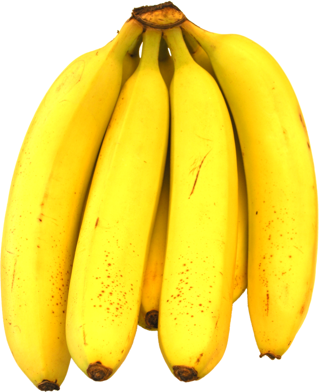

In [2]:
cover_array = load_png_from_path(sample_png_path)
cover_carrier = rgb_array_to_carrier(cover_array)
cover_image = Image.fromarray(cover_array, mode="RGB")
cover_display = cover_image.copy()
cover_display.thumbnail((320, 392))
print("Input path:", sample_png_path)
print("Array shape:", cover_array.shape)
print("Array dtype:", cover_array.dtype)
display(cover_display)

### 2. The plan

Choose the message, metadata, start location, and LSB count before calling the
encoder. The capacity figures come from the loaded carrier array; packet overhead
still applies. Start location and LSB count are sender choices, not receiver inputs.

In [3]:
private_key, public_key = generate_rsa_keypair()
public_key_path = DEMO_DIR / "banana-public-key.pem"
stego_png_path = DEMO_DIR / "banana-stego.png"
save_rsa_public_key_pem(public_key, public_key_path)
start_unit = 4096
lsb_count = 3
image_message = b"INF2005 end-to-end image demonstration"
image_metadata = b"kind=png;flow=sender-receiver"
print(f"Carrier units: {cover_array.shape[1]}*{cover_array.shape[0]}*{cover_array.shape[2]} = {cover_carrier.size}")
print(f"Capacity at k={lsb_count}: {cover_carrier.size * lsb_count} bits ({cover_carrier.size * lsb_count // 8} bytes before packet overhead)")
print("Start unit:", start_unit)
print("LSB count:", lsb_count)
print("Message bytes:", image_message)
print("Metadata:", image_metadata)
print("Public-key fingerprint:", display_rsa_public_key_fingerprint(public_key))

Carrier units: 1280*1568*3 = 6021120
Capacity at k=3: 18063360 bits (2257920 bytes before packet overhead)
Start unit: 4096
LSB count: 3
Message bytes: b'INF2005 end-to-end image demonstration'
Metadata: b'kind=png;flow=sender-receiver'
Public-key fingerprint: SHA256:mrwbGf6zIzXgVR2ykkPClNlV/BpbUkjsTHwOpY8yiM8


### 3. The act

This is the only sender operation that creates the signed stego packet. The cell
contains one call to the real file adapter; packet construction remains in `stego`.

In [4]:
png_layout, png_payload = encode_png(
    sample_png_path,
    stego_png_path,
    private_key,
    start_unit=start_unit,
    lsb_count=lsb_count,
    user_payload=image_message,
    metadata=image_metadata,
)

### 4. What it built

Inspect the exact layout and payload records returned by `encode_png`. The
serialized payload hexdump is produced by the package's `serialize_payload`, not
by rebuilding a second record in the notebook.

In [5]:
print("Layout.start_unit:", png_layout.start_unit)
print("Layout.lsb_count:", png_layout.lsb_count)
print("Layout.payload_length:", png_layout.payload_length)
print("Layout.footprint:", png_layout.footprint)
print("Layout.pad_bits:", png_layout.pad_bits)
print("Payload.media_id:", png_payload.media_id)
print("Payload.timestamp (integer):", png_payload.timestamp)
print("Payload.timestamp (UTC):", datetime.fromtimestamp(png_payload.timestamp, timezone.utc).isoformat())
print("Payload.nonce (hex):", png_payload.nonce.hex())
print("Payload.media_hash (hex):", png_payload.media_hash.hex())
print("Payload.user_payload:", png_payload.user_payload)
print("Payload.metadata:", png_payload.metadata)
png_payload_bytes = serialize_payload(png_payload)
print("Serialized payload hexdump:", png_payload_bytes.hex(" "))

Layout.start_unit: 4096
Layout.lsb_count: 3
Layout.payload_length: 168
Layout.footprint: 1192
Layout.pad_bits: 0
Payload.media_id: IMG-b65f9b2bd151dc799314f2f9204a4c07
Payload.timestamp (integer): 1789208417
Payload.timestamp (UTC): 2026-09-12T10:20:17+00:00
Payload.nonce (hex): a3ba6f8e0f018d3330388cbeaf7965da
Payload.media_hash (hex): 24b3d7842a0c10397356a07ab6d8c3ed7033d9713896bfae17a02b408afd030e
Payload.user_payload: b'INF2005 end-to-end image demonstration'
Payload.metadata: b'kind=png;flow=sender-receiver'
Serialized payload hexdump: 24 49 4d 47 2d 62 36 35 66 39 62 32 62 64 31 35 31 64 63 37 39 39 33 31 34 66 32 66 39 32 30 34 61 34 63 30 37 00 00 00 00 6a a5 27 61 a3 ba 6f 8e 0f 01 8d 33 30 38 8c be af 79 65 da 24 b3 d7 84 2a 0c 10 39 73 56 a0 7a b6 d8 c3 ed 70 33 d9 71 38 96 bf ae 17 a0 2b 40 8a fd 03 0e 00 00 00 26 49 4e 46 32 30 30 35 20 65 6e 64 2d 74 6f 2d 65 6e 64 20 69 6d 61 67 65 20 64 65 6d 6f 6e 73 74 72 61 74 69 6f 6e 00 00 00 1d 6b 69 6e 64 3d 70 6e 67 3b 66 6c 6f 

### Optional signed bytes

This display calls the real signing-input builder with the returned layout and
serialized payload bytes. **RE-DERIVED FOR DISPLAY ONLY:** the signature itself
was produced inside `encode_png`; this cell does not sign anything.

In [6]:
# RE-DERIVED FOR DISPLAY ONLY; encode_png produced the signature internally.
png_signed_input = encode_signing_input(
    IMAGE_MEDIA_CODE,
    encode_png_media_context(cover_array.shape, cover_carrier.size),
    png_layout,
    png_payload_bytes,
)
print("Signed-input length:", len(png_signed_input))
print("Signed-input first 96 bytes:", png_signed_input[:96].hex(" "))

Signed-input length: 225
Signed-input first 96 bytes: 49 4e 46 32 30 30 35 2d 41 43 57 31 00 53 49 47 4e 00 01 01 03 00 00 00 00 00 5b e0 00 00 00 00 00 00 00 10 00 00 00 00 00 00 00 04 a8 00 00 00 a8 00 00 05 00 00 00 06 20 24 49 4d 47 2d 62 36 35 66 39 62 32 62 64 31 35 31 64 63 37 39 39 33 31 34 66 32 66 39 32 30 34 61 34 63 30 37 00 00


### 5. The product

Now inspect the file written by the adapter. The normal-scale preview shows why
LSB changes are visually nil; the zoomed crop is centred on the returned embedding
location so the small carrier changes can be seen.

Stego path: /tmp/inf2005-demo-5e0kio_0/banana-stego.png
Stego file bytes: 1674475
Differing pixel values: 1070
Normal-scale cover (left) and stego (right):


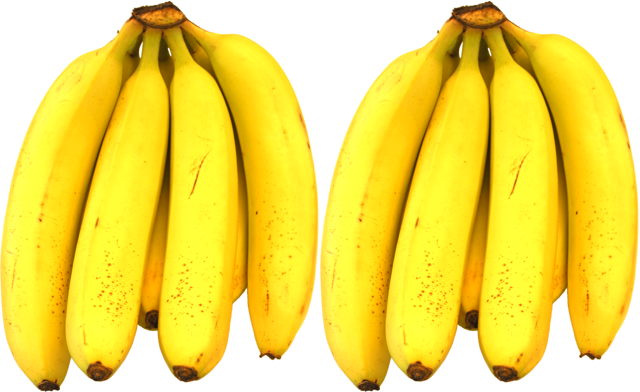

Zoomed crop: cover (left), stego (right):


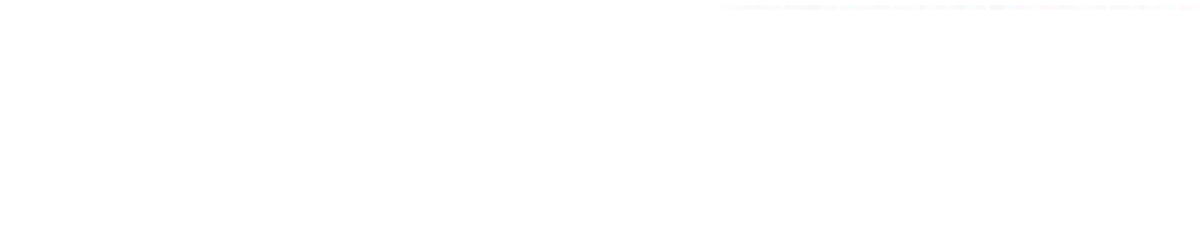

In [7]:
stego_array = load_png_from_path(stego_png_path)
stego_image = Image.fromarray(stego_array, mode="RGB")
print("Stego path:", stego_png_path)
print("Stego file bytes:", stego_png_path.stat().st_size)
print("Differing pixel values:", int(np.count_nonzero(stego_array != cover_array)))

cover_normal = cover_image.copy()
stego_normal = stego_image.copy()
cover_normal.thumbnail((320, 392))
stego_normal.thumbnail((320, 392))
normal_pair = Image.new("RGB", (cover_normal.width + stego_normal.width, max(cover_normal.height, stego_normal.height)))
normal_pair.paste(cover_normal, (0, 0))
normal_pair.paste(stego_normal, (cover_normal.width, 0))
print("Normal-scale cover (left) and stego (right):")
display(normal_pair)

start_pixel = png_layout.start_unit // cover_array.shape[2]
start_y, start_x = divmod(start_pixel, cover_array.shape[1])
crop_box = (
    max(0, start_x - 24),
    max(0, start_y - 12),
    min(cover_array.shape[1], start_x + 96),
    min(cover_array.shape[0], start_y + 48),
)
cover_crop = cover_image.crop(crop_box)
stego_crop = stego_image.crop(crop_box)
zoom_size = (cover_crop.width * 5, cover_crop.height * 5)
zoom_pair = Image.new("RGB", (zoom_size[0] * 2, zoom_size[1]))
zoom_pair.paste(cover_crop.resize(zoom_size, Image.Resampling.NEAREST), (0, 0))
zoom_pair.paste(stego_crop.resize(zoom_size, Image.Resampling.NEAREST), (zoom_size[0], 0))
print("Zoomed crop: cover (left), stego (right):")
display(zoom_pair)

### End of sender state

The sender has finished. Delete the signing key, layout, payload, cover pixels, and
embedding choices before the receiver section.

In [8]:
# Sender-only state is deliberately discarded before the receiver acts.
del private_key
del public_key, png_layout, png_payload, png_payload_bytes, png_signed_input
del cover_array, cover_carrier, cover_image, cover_display, stego_array, stego_image
del cover_normal, stego_normal, normal_pair, cover_crop, stego_crop, zoom_pair
del start_unit, lsb_count, image_message, image_metadata, start_pixel, start_y, start_x, crop_box, zoom_size

## Act 2 — Receiver: discover and verify

The sender's signing key and embedding state are gone. The receiver now works from
files, and the decoder discovers the embedding parameters instead of receiving
them.

### 1. What the receiver has

Only these two paths cross the sender/receiver boundary: the stego image and the
public-key PEM. `start_unit` and `lsb_count` were never transmitted.

In [9]:
print("Stego file path:", stego_png_path)
print("Public-key PEM path:", public_key_path)

Stego file path: /tmp/inf2005-demo-5e0kio_0/banana-stego.png
Public-key PEM path: /tmp/inf2005-demo-5e0kio_0/banana-public-key.pem


### 2. The scan — discovery before verification

Load the stego carrier and ask the real scanner for start-magic candidates. This is
where the receiver discovers the sender's start unit and LSB count.

In [10]:
receiver_image = load_png_from_path(stego_png_path)
receiver_carrier = rgb_array_to_carrier(receiver_image)
receiver_candidates = scan_start_magic(receiver_carrier)
print("Scanned candidates:", [{"start_unit": candidate.start_unit, "lsb_count": candidate.lsb_count} for candidate in receiver_candidates])

Scanned candidates: [{'start_unit': 4096, 'lsb_count': 3}]


### 3. The verify

Load the public key from its PEM path and verify the stego file. The result exposes
the signed payload fields recovered by the receiver.

In [11]:
receiver_public_key = load_rsa_public_key_pem(public_key_path)
png_result = verify_png(stego_png_path, receiver_public_key)
print("PNG verdict:", png_result.verdict)
print("Media ID:", png_result.payload.media_id)
print("Timestamp:", png_result.payload.timestamp)
print("Recovered message:", png_result.payload.user_payload.decode("utf-8"))

PNG verdict: Authentic
Media ID: IMG-b65f9b2bd151dc799314f2f9204a4c07
Timestamp: 1789208417
Recovered message: INF2005 end-to-end image demonstration


## Act 3 — Failure cases

These checks use the same receiver inputs but change the carrier or the supplied
public key. They show the protocol's distinct verdicts.

In [12]:
altered_png_path = DEMO_DIR / "banana-altered.png"
altered_image = load_png_from_path(stego_png_path)
altered_carrier = rgb_array_to_carrier(altered_image)
altered_carrier[-1] ^= np.uint8(1)
save_rgb_png_to_path(carrier_to_rgb_array(altered_carrier, altered_image.shape), altered_png_path)
print("Altered PNG verdict:", verify_png(altered_png_path, receiver_public_key).verdict)

actionless_private_key, wrong_public_key = generate_rsa_keypair()
del actionless_private_key
print("Wrong-key PNG verdict:", verify_png(stego_png_path, wrong_public_key).verdict)
print("Untouched cover verdict:", verify_png(sample_png_path, receiver_public_key).verdict)
del wrong_public_key, altered_image, altered_carrier

Altered PNG verdict: Tampered
Wrong-key PNG verdict: Signature Invalid


Untouched cover verdict: Payload Missing


## Act 4 — WAV: the same story, condensed

For audio, the sender creates a short mono 8-bit PCM sine tone in the temporary
directory, embeds a message, and publishes its public key. The receiver then
verifies from the two file paths; one altered frame demonstrates tamper detection.

In [13]:
wav_cover_path = DEMO_DIR / "tone-cover.wav"
wav_stego_path = DEMO_DIR / "tone-stego.wav"
wav_public_key_path = DEMO_DIR / "tone-public-key.pem"
wav_altered_path = DEMO_DIR / "tone-altered.wav"
wav_samples = (128 + 90 * np.sin(2 * np.pi * 440 * np.arange(32000) / 8000)).astype(np.uint8).tobytes()
with wave.open(str(wav_cover_path), "wb") as wav_file:
    wav_file.setnchannels(1)
    wav_file.setsampwidth(1)
    wav_file.setframerate(8000)
    wav_file.writeframes(wav_samples)

wav_private_key, wav_public_key = generate_rsa_keypair()
wav_start_unit = 61
wav_lsb_count = 5
wav_layout, wav_payload = encode_wav(
    wav_cover_path,
    wav_stego_path,
    wav_private_key,
    start_unit=wav_start_unit,
    lsb_count=wav_lsb_count,
    user_payload=b"INF2005 end-to-end audio demonstration",
    metadata=b"kind=wav;flow=sender-receiver",
)
save_rsa_public_key_pem(wav_public_key, wav_public_key_path)

# Keep the WAV receiver step independent of the sender's key and layout too.
del wav_private_key, wav_public_key, wav_layout, wav_payload, wav_samples
del wav_start_unit, wav_lsb_count
wav_receiver_key = load_rsa_public_key_pem(wav_public_key_path)
wav_result = verify_wav(wav_stego_path, wav_receiver_key)
print("WAV verdict:", wav_result.verdict)
print("WAV recovered message:", wav_result.payload.user_payload.decode("utf-8"))

wav_data = load_pcm_wav_from_path(wav_stego_path)
wav_carrier = wav_frame_bytes_to_carrier(wav_data.frame_bytes)
wav_carrier[-1] ^= np.uint8(1)
save_pcm_wav_to_path(wav_data_with_carrier(wav_data, wav_carrier), wav_altered_path)
print("Altered WAV verdict:", verify_wav(wav_altered_path, wav_receiver_key).verdict)
del wav_data, wav_carrier

WAV verdict: Authentic
WAV recovered message: INF2005 end-to-end audio demonstration
Altered WAV verdict: Tampered


## Appendix — Analysis: compare k=1 and k=8

This is a visual and layout comparison, not part of the sender-to-receiver flow.
Both encodings use the full-resolution cover; only the previews are downscaled.

{'k': 1, 'capacity_bits': 6021120, 'packet_bits': 3376, 'footprint': 3376, 'changed_values': 1793, 'preserved_ratio': '99.99%', 'verdict': 'Authentic'}
{'k': 8, 'capacity_bits': 48168960, 'packet_bits': 3376, 'footprint': 422, 'changed_values': 422, 'preserved_ratio': '99.99%', 'verdict': 'Authentic'}
Cover (left), k=1 (middle), and k=8 (right), downscaled for display:


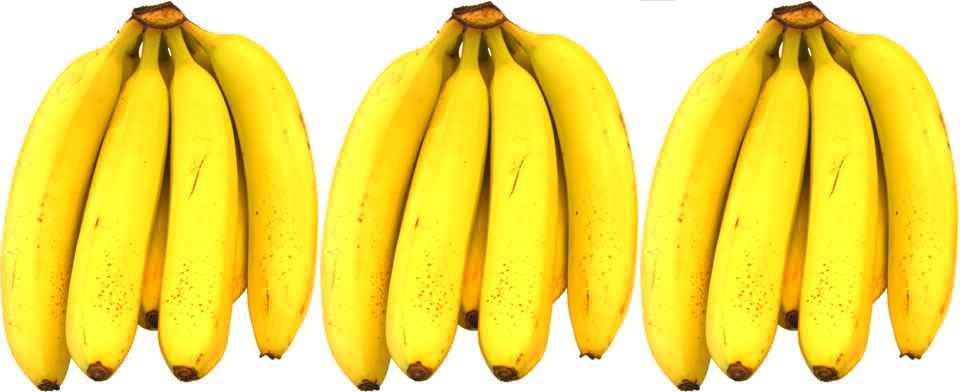

In [14]:
analysis_private_key, analysis_public_key = generate_rsa_keypair()
analysis_rows = []
analysis_previews = []
analysis_cover_array = load_png_from_path(sample_png_path)
analysis_cover_image = Image.fromarray(analysis_cover_array, mode="RGB")
for analysis_k in (1, 8):
    analysis_output = DEMO_DIR / f"banana-analysis-k{analysis_k}.png"
    analysis_layout, _ = encode_png(
        sample_png_path,
        analysis_output,
        analysis_private_key,
        start_unit=0,
        lsb_count=analysis_k,
        user_payload=b"same analysis payload",
        metadata=b"analysis=k comparison",
    )
    analysis_result = verify_png(analysis_output, analysis_public_key)
    analysis_image = np.asarray(Image.open(analysis_output), dtype=np.uint8)
    changed_values = int(np.count_nonzero(analysis_image != analysis_cover_array))
    preserved = preserved_bit_count(analysis_layout.total_units, analysis_layout.footprint, analysis_layout.lsb_count)
    packet_bits = (PACKET_HEADER_SIZE + analysis_layout.payload_length + RSA_SIGNATURE_SIZE) * 8
    analysis_rows.append({
        "k": analysis_k,
        "capacity_bits": analysis_layout.total_units * analysis_k,
        "packet_bits": packet_bits,
        "footprint": analysis_layout.footprint,
        "changed_values": changed_values,
        "preserved_ratio": f"{preserved / (analysis_layout.total_units * 8):.2%}",
        "verdict": analysis_result.verdict,
    })
    analysis_preview = Image.fromarray(analysis_image, mode="RGB")
    analysis_preview.thumbnail((320, 392))
    analysis_previews.append(analysis_preview)
for row in analysis_rows:
    print(row)
analysis_comparison = Image.new("RGB", (analysis_cover_image.width // 4 * 3, analysis_cover_image.height // 4))
analysis_cover_preview = analysis_cover_image.resize((analysis_cover_image.width // 4, analysis_cover_image.height // 4))
analysis_comparison.paste(analysis_cover_preview, (0, 0))
for index, analysis_preview in enumerate(analysis_previews, start=1):
    analysis_comparison.paste(analysis_preview, (index * analysis_cover_preview.width, 0))
print("Cover (left), k=1 (middle), and k=8 (right), downscaled for display:")
display(analysis_comparison)
del analysis_private_key, analysis_public_key, analysis_cover_array, analysis_cover_image, analysis_rows, analysis_previews, analysis_comparison, analysis_cover_preview

## Finish

All generated artifacts are temporary demonstration outputs.

In [15]:
_demo_temp.cleanup()
print("Temporary demonstration files removed.")

Temporary demonstration files removed.
